# Spark Tavsiye Sistemleri

Hatırlarsanız 4. Proje konularımızı işlerken Tavsiye Sistemlerine giriş yapmıştık. Bu notebookda ise benzer çalışmaları Spark'ın kendi yöntemi olan ALS'yi kullanarak ve Spark'ın bize sağlamış olduğu avantajlardan yararlanarak gerçekleştireceğiz.

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import requests, os, sys, zipfile, io
import pyspark

In [0]:
spark = pyspark.sql.SparkSession.builder.getOrCreate() 

## Veri Setini Oluşturma

Bu çalışmamızda kullanmak için `http://files.grouplens.org/datasets/movielens` adresindeki verilerden yararlanacağız. Eğer farklı veri setlerini incelemek isterseniz, sadece aşağıdaki `filepath` değişkenini değiştirmeniz yeterli :)

- **Small:** 100,000 Ratings and 2,488 tag applications applied to 8,570 movies by 706 users. Last updated 4/2015.
- **Full:** 21,000,000 Ratings and 470,000 tag applications applied to 27,000 movies by 230,000 users. Last updated 4/2015.

In [0]:
filepath = 'ml-latest-small'  # 'ml-latest' --> Veri setinin büyük hali

url = 'http://files.grouplens.org/datasets/movielens/{}.zip'.format(filepath)

filename = 'movies.csv'
fullpath = os.sep.join([filepath, filename])

if not os.path.exists(fullpath):    
    sess = requests.session()
    resp = sess.get(url)
    zipdata = zipfile.ZipFile(io.BytesIO(resp.content))
    zipdata.extractall()

In [0]:
fullpath

Out[4]: 'ml-latest-small/movies.csv'

Şimdi de kullanacağımız veri setlerinin içeriğini inceleyelim.

In [0]:
!cat {filepath}/movies.csv # Veri setinin tümüne bakalım

















































































































































































































































































































































































































































































































































616,"Aris

*** WARNING: max output size exceeded, skipping output. ***



















































































































































































































































































































































































































In [0]:
!head -n 5 {filepath}/ratings.csv  # Sadece ilk 5 satırına bakalım

In [0]:
!head -n 5 {filepath}/links.csv

In [0]:
!head -n 5 {filepath}/tags.csv

>**SORU:** Eğer bir film öneri sistemi oluşturmak istiyorsak sizce hangi csv dosyasını kullanmalıyız?

Artık bu verilerimizi Spark kullanarak okuyabiliriz.

In [0]:
from pyspark.sql.functions import col

abs_path = 'dbfs:/FileStore/tables'
ratings = spark.read.csv(abs_path + '/ratings.csv',
                        inferSchema=True,
                        header=True)

for column in ['userId','movieId','timestamp']:
    ratings = ratings.withColumn('rating', col('rating').cast('int'))
    
ratings.printSchema()

root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: integer (nullable = true)
 |-- timestamp: integer (nullable = true)



In [0]:
ratings.show()

+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|     1|      1|     4|964982703|
|     1|      3|     4|964981247|
|     1|      6|     4|964982224|
|     1|     47|     5|964983815|
|     1|     50|     5|964982931|
|     1|     70|     3|964982400|
|     1|    101|     5|964980868|
|     1|    110|     4|964982176|
|     1|    151|     5|964984041|
|     1|    157|     5|964984100|
|     1|    163|     5|964983650|
|     1|    216|     5|964981208|
|     1|    223|     3|964980985|
|     1|    231|     5|964981179|
|     1|    235|     4|964980908|
|     1|    260|     5|964981680|
|     1|    296|     3|964982967|
|     1|    316|     3|964982310|
|     1|    333|     5|964981179|
|     1|    349|     4|964982563|
+------+-------+------+---------+
only showing top 20 rows



Devam etmeden önce veri setimizi biraz daha detaylı inceleyelim.

In [0]:
ratings.describe().show()

+-------+------------------+----------------+-----------------+--------------------+
|summary|            userId|         movieId|           rating|           timestamp|
+-------+------------------+----------------+-----------------+--------------------+
|  count|            100836|          100836|           100836|              100836|
|   mean|326.12756356856676|19435.2957177992|3.350827085564679|1.2059460873684695E9|
| stddev| 182.6184914635004|35530.9871987003|1.089267690224751|2.1626103599513078E8|
|    min|                 1|               1|                0|           828124615|
|    max|               610|          193609|                5|          1537799250|
+-------+------------------+----------------+-----------------+--------------------+



**NOT:** Eğer PySpark kullanarak yaptığınız incelemeler yetersiz geliyorsa, veri setinizi Pandas DataFrame haline getirip Pandas'ın özelliklerini kullanarak da yapabiliriz. Ya da SQL yazarak :)

In [0]:
pd_df = ratings.toPandas()
pd_df.describe()

,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,1.008360e+05
mean,326.127564,19435.295718,3.350827,1.205946e+09
std,182.618491,35530.987199,1.089268,2.162610e+08
min,1.000000,1.000000,0.000000,8.281246e+08
25%,177.000000,1199.000000,3.000000,1.019124e+09
50%,325.000000,2991.000000,3.000000,1.186087e+09
75%,477.000000,8122.000000,4.000000,1.435994e+09
max,610.000000,193609.000000,5.000000,1.537799e+09


In [0]:
ratings.createOrReplaceTempView("ratings")

spark.sql('SELECT rating, COUNT(*) FROM ratings GROUP BY rating ORDER BY 1').show()

+------+--------+
|rating|count(1)|
+------+--------+
|     0|    1370|
|     1|    4602|
|     2|   13101|
|     3|   33183|
|     4|   35369|
|     5|   13211|
+------+--------+



Veri setimizi train ve test olmak üzere 2 parçaya ayıralım.

In [0]:
train, test = ratings.randomSplit([0.8, 0.2], seed=42)

## Spark ALS (Alternative Least Squares)

Let's build our first reocmmendation system using PySpark's alternative least squares (ALS) matrix factorization. We will begin by using rank 4 matrices in the factorization. The rank (as well as many other factors), can be updated later using a grid search.

In [0]:
from pyspark.ml.recommendation import ALS

# ALS'yi tanımlama
als = ALS(userCol='userId',
          itemCol='movieId',
          ratingCol='rating',
          seed=42)

# Modeli eğit
als_model = als.fit(train)

# Test veri setindeki bilgileri kullanarak tahmin et
als_pred = als_model.transform(test)

In [0]:
als_pred.show()

+------+-------+------+---------+----------+
|userId|movieId|rating|timestamp|prediction|
+------+-------+------+---------+----------+
|     1|    101|     5|964980868| 4.0137453|
|     1|   1031|     5|964982653| 4.7244544|
|     1|    596|     5|964982838| 4.0707803|
|     1|   1197|     5|964981872|   5.07847|
|     1|      6|     4|964982224|  4.606478|
|     1|   1089|     5|964982951| 4.7027545|
|     1|    923|     5|964981529|  4.422875|
|     1|   1220|     5|964981909| 4.5235767|
|     1|    231|     5|964981179| 3.9571795|
|     1|   1967|     4|964981710| 4.2936525|
|     1|    423|     3|964982363| 2.8122606|
|     1|    543|     4|964981179|  4.293833|
|     1|    151|     5|964984041| 4.2845097|
|     1|    943|     4|964983614| 4.0357547|
|     1|    940|     5|964982176|  4.231883|
|     1|   1573|     5|964982290|  4.128715|
|     1|   1024|     5|964982876| 4.1954083|
|     1|    349|     4|964982563| 4.0183105|
|     1|   2000|     4|964982211|  4.747672|
|     1|  

Artık tahminlerimizin ne kadar isabetli olduğuna bakabiliriz. Bu aradaki farklı belirlemek için basit bir formülasyon kullanalım.

In [0]:
als_pred = als_pred.withColumn('diff_sq', (als_pred['rating'] - als_pred['prediction'])**2)

als_pred[['rating','prediction','diff_sq']].show()

+------+----------+--------------------+
|rating|prediction|             diff_sq|
+------+----------+--------------------+
|     3| 3.7845447|  0.6155103962533417|
|     2|  3.642455|   2.697658758844227|
|     3| 3.3837872|  0.1472925804591796|
|     5| 3.4002075|   2.559335980564356|
|     4|  4.088349|0.007805522036733237|
|     4| 3.4496107|  0.3029283703881447|
|     2|  2.282194| 0.07963339672011216|
|     4| 3.1145298|  0.7840573899080141|
|     4| 4.0911274|0.008304202234285185|
|     2| 2.3542233| 0.12547411179184564|
|     1| 3.2268875|    4.95902777965108|
|     4|  4.206805|0.042768402819092444|
|     3| 2.6696107|  0.1091570639464976|
|     3| 3.5149693|  0.2651934303141843|
|     3| 3.2809408| 0.07892771686789501|
|     4|   3.70535| 0.08681866835922847|
|     2| 2.0748549|0.005603248683655693|
|     3| 3.2153392|0.046370964082825594|
|     3|  3.169211| 0.02863233233279061|
|     3| 3.3817067| 0.14570001599372517|
+------+----------+--------------------+
only showing top

Regresyon derslerinden RMSE metriğini hatırlıyor musunuz? Şimdi de RMSE değerini hesaplayarak modelimizin başarısını görelim. 

>**NOT:** Yaptığımız işlem sonucunda NaN değerlerle karşılaşmamız için onlardan kurturalım.

In [0]:
from pyspark.sql import functions as func

rms_calc = func.sqrt(func.mean('diff_sq'))

als_pred.dropna().select(rms_calc.alias('rmse')).show()

+------------------+
|              rmse|
+------------------+
|0.9297166987668761|
+------------------+



>**SORU:** Elde edilen RMSE değerine baktığınızda modelin başarısı hakkında ne söyleyebilirsiniz?

## ParamGridBuilder Parametre Optimizasyonu

Şimdi de aynı modeli en iyi parametreleri de belirleyerek tekrardan oluşturalım ve sonrasında model doğruluğunu tekrardan gözlemleyelim.

In [0]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import RegressionEvaluator

# ALS'yi tanımlama
als = ALS(userCol='userId',
          itemCol='movieId',
          ratingCol='rating',
          seed=42)

# Optimize etmek istediğimiz parametreler (uzun sürebilir)
als_paramgrid = (ParamGridBuilder()
                 .addGrid(als.rank, [2, 4])
                 .addGrid(als.maxIter, [10])
                 .addGrid(als.regParam, [0.1])
                 .addGrid(als.alpha, [2.0, 3.0])
                 .build())

# RMSE değeri hesabı
rmse_eval = RegressionEvaluator(labelCol='rating',
                                predictionCol='prediction', 
                                metricName='rmse')

# Cross-Validation
als_cv = CrossValidator(estimator=als,
                        estimatorParamMaps=als_paramgrid,
                        evaluator=rmse_eval,
                        numFolds=3, 
                        seed=42)

# Modeli eğit
als_cv = als_cv.fit(train)

Bulduğumuz en iyi parametrelere bakalım.

In [0]:
als_best = als_cv.bestModel

print('Best Rank:', als_best.rank)
print('Best Alpha:', als_best._java_obj.parent().getAlpha())

Best Rank: 2
Best Alpha: 2.0


Şimdi de optimize ettiğimiz parametrelerin model sonucunda yarattığı başarı farkına bakalım.

In [0]:
als_pred_best = als_best.transform(test) # Parametre optimizasyondan sonra elde edilen RMSE

als_best_rmse = pd.DataFrame([(rmse_eval.evaluate(als_pred.dropna()),
                               rmse_eval.evaluate(als_pred_best.dropna()))],
                             columns=['rmse_original', 'rmse_crossval'])

als_best_rmse

,rmse_original,rmse_crossval
0,0.929717,0.919084


Son olarak da yaptığımız tahminlerin doğruluklarını, sapma miktarlarını biraz daha detaylı incelemek için basit bir görselleştirme çalışması yapalım.

In [0]:
als_pred_best_df = als_pred_best.dropna().toPandas() # Görsel oluşturmak için Pandas DataFrame dönüşümü

Out[23]: (-0.5, 5.5)

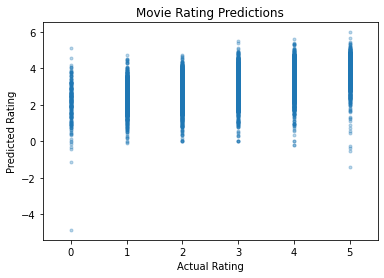

In [0]:
ax = als_pred_best_df.plot('rating','prediction', 
                           marker='o', ls='', ms=3,
                           alpha=0.3, legend=False)

ax.set(xlabel='Actual Rating', ylabel='Predicted Rating', title='Movie Rating Predictions')
ax.set_xlim(-0.5, 5.5)

Artık oluşturduğumuz modeli kullanarak kullanıcılara çeşitli film önerilerinde bulunmaya başlayabiliriz :)

In [0]:
recommendations = als_best.recommendForAllUsers(5)
recommendations.show()

+------+--------------------+
|userId|     recommendations|
+------+--------------------+
|     1|[{141718, 7.14406...|
|     2|[{26171, 6.081457...|
|     3|[{89118, 8.321341...|
|     4|[{26171, 6.057015...|
|     5|[{141718, 5.69747...|
|     6|[{26171, 7.184324...|
|     7|[{141718, 4.97996...|
|     8|[{141718, 6.09373...|
|     9|[{2068, 7.030672}...|
|    10|[{26171, 7.108250...|
|    11|[{141718, 6.60164...|
|    12|[{26171, 8.486548...|
|    13|[{26171, 6.484471...|
|    14|[{26171, 6.356295...|
|    15|[{141718, 5.31790...|
|    16|[{25771, 5.032036...|
|    17|[{141718, 5.93199...|
|    18|[{141718, 5.55279...|
|    19|[{141718, 4.78841...|
|    20|[{25771, 6.079378...|
+------+--------------------+
only showing top 20 rows



Bu DataFrame'den bir şey anlamak oldukça zor. O yüzden yapılan bu önerileri daha anlaşılabilir bir formata dönüştürelim.

In [0]:
from pyspark.sql.functions import explode

recommendations_table = recommendations.withColumn('splited', explode('recommendations')).select('userId', col("splited.movieId"), col("splited.rating"))
recommendations_table.show(10)

+------+-------+---------+
|userId|movieId|   rating|
+------+-------+---------+
|     1| 141718| 7.144066|
|     1| 136469| 6.584734|
|     1|  25771|6.5251684|
|     1|  26171|6.4893756|
|     1| 102217| 6.460224|
|     2|  26171| 6.081457|
|     2| 141718|5.8176985|
|     2|  67618| 5.435356|
|     2|  89759| 5.316326|
|     2|   6611|5.3133426|
+------+-------+---------+
only showing top 10 rows



>**SORU:** 141718 numaralı film ne peki? Bu filmin hangi film olduğunu nasıl bilebilirim?

In [0]:
movies = spark.read.csv(abs_path + '/movies.csv',
                        inferSchema=True,
                        header=True)

movies.show()

+-------+--------------------+--------------------+
|movieId|               title|              genres|
+-------+--------------------+--------------------+
|      1|    Toy Story (1995)|Adventure|Animati...|
|      2|      Jumanji (1995)|Adventure|Childre...|
|      3|Grumpier Old Men ...|      Comedy|Romance|
|      4|Waiting to Exhale...|Comedy|Drama|Romance|
|      5|Father of the Bri...|              Comedy|
|      6|         Heat (1995)|Action|Crime|Thri...|
|      7|      Sabrina (1995)|      Comedy|Romance|
|      8| Tom and Huck (1995)|  Adventure|Children|
|      9| Sudden Death (1995)|              Action|
|     10|    GoldenEye (1995)|Action|Adventure|...|
|     11|American Presiden...|Comedy|Drama|Romance|
|     12|Dracula: Dead and...|       Comedy|Horror|
|     13|        Balto (1995)|Adventure|Animati...|
|     14|        Nixon (1995)|               Drama|
|     15|Cutthroat Island ...|Action|Adventure|...|
|     16|       Casino (1995)|         Crime|Drama|
|     17|Sen

In [0]:
new_recommendations_table = recommendations_table.join(movies, on='movieId')
new_recommendations_table.show()

+-------+------+---------+--------------------+--------------------+
|movieId|userId|   rating|               title|              genres|
+-------+------+---------+--------------------+--------------------+
| 141718|     1| 7.144066|    Deathgasm (2015)|       Comedy|Horror|
| 136469|     1| 6.584734|Larry David: Curb...|              Comedy|
|  25771|     1|6.5251684|Andalusian Dog, A...|             Fantasy|
|  26171|     1|6.4893756|Play Time (a.k.a....|              Comedy|
| 102217|     1| 6.460224|Bill Hicks: Revel...|              Comedy|
|  26171|     2| 6.081457|Play Time (a.k.a....|              Comedy|
| 141718|     2|5.8176985|    Deathgasm (2015)|       Comedy|Horror|
|  67618|     2| 5.435356|Strictly Sexual (...|Comedy|Drama|Romance|
|  89759|     2| 5.316326|Separation, A (Jo...|               Drama|
|   6611|     2|5.3133426|   Umberto D. (1952)|               Drama|
|  89118|     3|8.3213415|Skin I Live In, T...|               Drama|
|   2068|     3| 8.046354|Fanny an